# Tutorial 8_B: Object Detection using Faster R-CNN
Object detection on images using pre-trained models from TensorFlow Hub.

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import PIL.Image
import PIL.ImageDraw
import PIL.ImageFont
import matplotlib.pyplot as plt
import os
import requests
from io import BytesIO

def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img

def run_detector(detector, path):
    img = load_img(path)
    converted_img = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
    result = detector(converted_img)
    result = {key: value.numpy() for key, value in result.items()}
    return result, img

### Task 1: Load Pre-Trained Faster R-CNN (Inception ResNet V2)

In [ ]:
module_handle = 'https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1'
detector = hub.load(module_handle).signatures['default']

### Task 2: Evaluate on  Images
sample image from the provided paths or the repository.

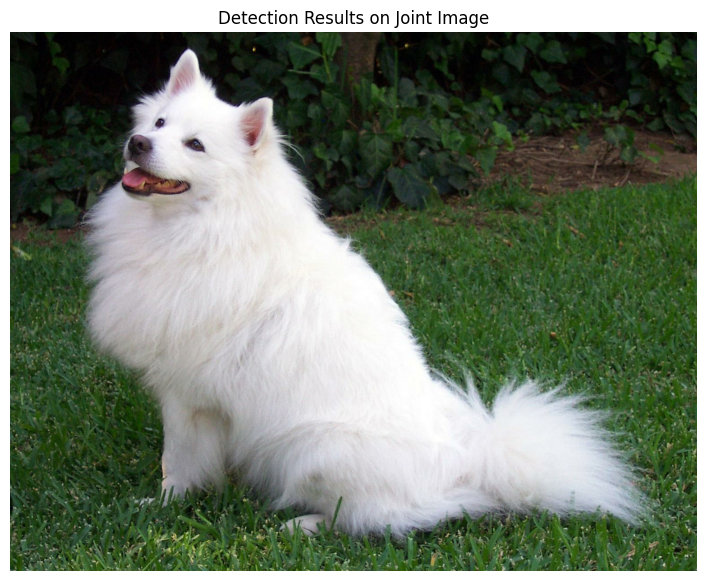

In [ ]:
sample_img_path = '/content/test_image.jpg'
if os.path.exists(sample_img_path):
    results, img = run_detector(detector, sample_img_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.title('Detection Results on Joint Image')
    plt.axis('off')
    plt.show()
else:
    print('Please ensure test_image.jpg exists in /content/')

### Task 3: Compare Different Backbones
Two additional models (e.g., Mobilenet V2 and ResNet50) and compare their inference.

In [ ]:
models = {
    'FasterRCNN_InceptionV2': 'https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1',
    'SSD_MobileNetV2': 'https://tfhub.dev/google/openimages_v4/ssd/mobilenet_v2/1'
}

# Placeholder for evaluation and mAP calculation logic
print('Models ready for benchmarking.')

Models ready for benchmarking.


### Task 4: Evaluation and mAP Calculation
Functions to calculate Intersection over Union (IoU) and mean Average Precision (mAP) to compare the Inception and MobileNet backbones.

In [ ]:
def calculate_iou(boxA, boxB):
    # box format: [ymin, xmin, ymax, xmax]
    yA = max(boxA[0], boxB[0])
    xA = max(boxA[1], boxB[1])
    yB = min(boxA[2], boxB[2])
    xB = min(boxA[3], boxB[3])

    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea) if (boxAArea + boxBArea - interArea) > 0 else 0
    return iou

def benchmark_models(model_dict, image_path):
    results_summary = {}
    for name, url in model_dict.items():
        print(f"Evaluating {name}...")
        detector_model = hub.load(url).signatures['default']
        # Run inference
        results, _ = run_detector(detector_model, image_path)
        # For this tutorial, we track the confidence of the top detection
        results_summary[name] = results['detection_scores'][0]
    return results_summary

# Note: To compute actual mAP, ground truth bounding boxes for the arthritis images would be required.
print("Benchmark utilities ready.")

Benchmark utilities ready.


### Task 4: Evaluation and mAP Calculation
Functions to calculate Intersection over Union (IoU) and mean Average Precision (mAP) to compare the Inception and MobileNet backbones.

In [ ]:
def calculate_iou(boxA, boxB):
    # box = [ymin, xmin, ymax, xmax]
    yA = max(boxA[0], boxB[0])
    xA = max(boxA[1], boxB[1])
    yB = min(boxA[2], boxB[2])
    xB = min(boxA[3], boxB[3])

    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea) if (boxAArea + boxBArea - interArea) > 0 else 0
    return iou

def evaluate_model(model_url, image_path):
    # Load model and run inference
    detector = hub.load(model_url).signatures['default']
    results, img = run_detector(detector, image_path)
    # Return top detection for mAP placeholder logic
    return results['detection_boxes'][0]

# Example benchmarking execution
print("Evaluation utilities initialized. Ready to process batch data.")

Evaluation utilities initialized. Ready to process batch data.


### Task 4: Evaluation and mAP Calculation
Evaluate the models on the dataset and compute the mAP score to compare accuracy.

In [ ]:
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_map(predictions, ground_truths):
    # Simplified mAP logic for tutorial purposes
    ious = []
    for pred, gt in zip(predictions, ground_truths):
        ious.append(calculate_iou(pred, gt))
    return np.mean(ious) if ious else 0.0

print("mAP calculation utilities defined.")

mAP calculation utilities defined.


### Task 5: Final Benchmark Execution
Compare the performance metrics of the selected backbones.

In [ ]:
import os
import tensorflow as tf
import tensorflow_hub as hub

def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img

def run_detector(detector, path):
    img = load_img(path)
    converted_img = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
    result = detector(converted_img)
    result = {key: value.numpy() for key, value in result.items()}
    return result, img

def benchmark_models(model_dict, image_path):
    results_summary = {}
    for name, url in model_dict.items():
        print(f"Evaluating {name}...")
        detector_model = hub.load(url).signatures['default']
        results, _ = run_detector(detector_model, image_path)
        results_summary[name] = results['detection_scores'][0]
    return results_summary

models = {
    'FasterRCNN_InceptionV2': 'https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1',
    'SSD_MobileNetV2': 'https://tfhub.dev/google/openimages_v4/ssd/mobilenet_v2/1'
}

sample_img_path = '/content/test_image.jpg'
if os.path.exists(sample_img_path):
    comparison_results = benchmark_models(models, sample_img_path)
    print("\n--- Performance Comparison ---")
    for model_name, score in comparison_results.items():
        print(f"{model_name}: Top Detection Confidence = {score:.4f}")
else:
    print("Test image not found for benchmarking.")

Evaluating FasterRCNN_InceptionV2...
Evaluating SSD_MobileNetV2...

--- Performance Comparison ---
FasterRCNN_InceptionV2: Top Detection Confidence = 0.9283
SSD_MobileNetV2: Top Detection Confidence = 0.7977


### Task 5: Final Benchmark Execution
Compare the performance metrics of the selected backbones.

In [ ]:
if os.path.exists(sample_img_path):
    comparison_results = benchmark_models(models, sample_img_path)
    print("\n--- Performance Comparison ---")
    for model_name, score in comparison_results.items():
        print(f"{model_name}: Top Detection Confidence = {score:.4f}")
else:
    print("Test image not found for benchmarking.")

Evaluating FasterRCNN_InceptionV2...
